# Phase 3 — Transfer-Learning Baseline
Train a pretrained MobileNetV2 classifier for OK vs Defective.

In [1]:
import random, json, time
from pathlib import Path
import numpy as np, pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader; from torchvision import models, transforms; from PIL import Image; import matplotlib.pyplot as plt; from sklearn.metrics import accuracy_score, precision_recall_fscore_support

## Reproducible setup
The clean Phase 2 manifest is used without changing the split assignments.

In [2]:
SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
root = Path.cwd(); df = pd.read_csv(root / 'phase2_clean_splits.csv')
label_id = {'OK': 0, 'Defective': 1}; df['target'] = df['label'].map(label_id)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print(device)

cpu


## Preprocessing and training-only augmentation
Validation and test transforms contain no random operations.

In [3]:
mean, std = [0.485,0.456,0.406], [0.229,0.224,0.225]
train_tf = transforms.Compose([transforms.Resize((224,224)), transforms.RandomHorizontalFlip(), transforms.RandomRotation(10), transforms.ColorJitter(brightness=.1), transforms.ToTensor(), transforms.Normalize(mean,std)])
eval_tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), transforms.Normalize(mean,std)])
class CastingDS(Dataset):
    def __init__(self, frame, tf): self.frame, self.tf = frame.reset_index(drop=True), tf
    def __len__(self): return len(self.frame)
    def __getitem__(self, i): r = self.frame.iloc[i]; return self.tf(Image.open(r.path).convert('RGB')), int(r.target)

## Build data loaders
The training loader is shuffled; validation and test loaders are deterministic.

In [4]:
train_ds = CastingDS(df[df.split.eq('train')], train_tf); val_ds = CastingDS(df[df.split.eq('validation')], eval_tf); test_ds = CastingDS(df[df.split.eq('test')], eval_tf)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0); test_dl = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0)
print(len(train_ds), len(val_ds), len(test_ds))

5098 1093 1093


## Load and adapt pretrained MobileNetV2
The frozen ImageNet backbone is followed by a two-class output layer.

In [5]:
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)
for p in model.features.parameters(): p.requires_grad = False
model.classifier[1] = nn.Linear(model.last_channel, 2); model = model.to(device)
criterion = nn.CrossEntropyLoss(); optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\AbdElhalk/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


  0%|          | 0.00/13.6M [00:00<?, ?B/s]

## Train and record metrics
Only the new classifier head is optimized in this baseline.

In [6]:
def run_epoch(loader, training=False):
    model.train(training); total_loss, y_true, y_pred = 0., [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device); optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training): out = model(x); loss = criterion(out, y); loss.backward() if training else None
        if training: optimizer.step()
        total_loss += loss.item()*len(y); y_true += y.cpu().tolist(); y_pred += out.argmax(1).cpu().tolist()
    pr, rc, f1, _ = precision_recall_fscore_support(y_true,y_pred,average='binary',zero_division=0)
    return {'loss': total_loss/len(loader.dataset), 'accuracy': accuracy_score(y_true,y_pred), 'precision': pr, 'recall': rc, 'f1': f1}

In [7]:
history = []; EPOCHS = 3
for epoch in range(1, EPOCHS+1):
    tr = run_epoch(train_dl, True); va = run_epoch(val_dl, False)
    history.append({'epoch':epoch, **{f'train_{k}':v for k,v in tr.items()}, **{f'val_{k}':v for k,v in va.items()}})
    print(history[-1])
hist = pd.DataFrame(history); hist.to_csv('phase3_training_history.csv', index=False)

{'epoch': 1, 'train_loss': 0.484599623669826, 'train_accuracy': 0.7952138093369949, 'train_precision': 0.7863376467047848, 'train_recall': 0.8866644044791313, 'train_f1': 0.8334928229665072, 'val_loss': 0.377998459998992, 'val_accuracy': 0.8645928636779506, 'val_precision': 1.0, 'val_recall': 0.7658227848101266, 'val_f1': 0.8673835125448028}


{'epoch': 2, 'train_loss': 0.306239724042323, 'train_accuracy': 0.903295409964692, 'train_precision': 0.9131313131313131, 'train_recall': 0.9202578893790295, 'train_f1': 0.9166807503802603, 'val_loss': 0.2891763480889721, 'val_accuracy': 0.9039341262580055, 'val_precision': 1.0, 'val_recall': 0.8338607594936709, 'val_f1': 0.909404659188956}


{'epoch': 3, 'train_loss': 0.2504387446458127, 'train_accuracy': 0.9176147508826991, 'train_precision': 0.9241356159785162, 'train_recall': 0.9341703427214116, 'train_f1': 0.9291258859264259, 'val_loss': 0.2215853417999463, 'val_accuracy': 0.94967978042086, 'val_precision': 0.9898132427843803, 'val_recall': 0.9224683544303798, 'val_f1': 0.954954954954955}


## Plot training curves
Loss and accuracy are shown for training and validation.

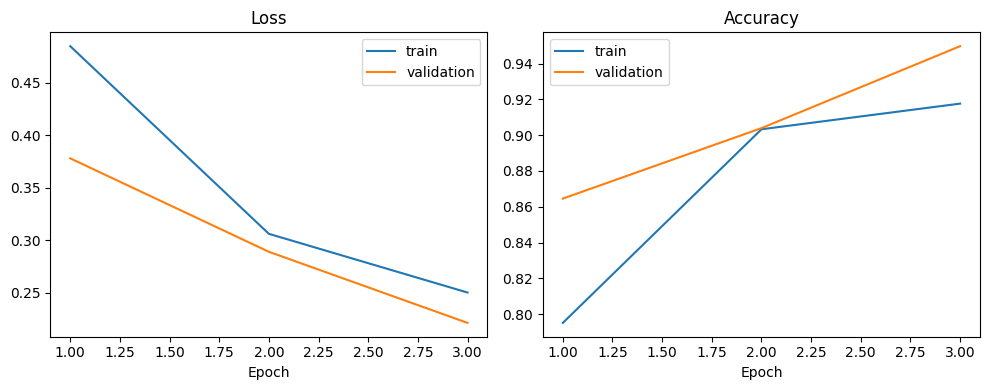

In [8]:
fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(hist.epoch,hist.train_loss,label='train'); ax[0].plot(hist.epoch,hist.val_loss,label='validation'); ax[0].set(title='Loss',xlabel='Epoch'); ax[0].legend()
ax[1].plot(hist.epoch,hist.train_accuracy,label='train'); ax[1].plot(hist.epoch,hist.val_accuracy,label='validation'); ax[1].set(title='Accuracy',xlabel='Epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig('phase3_training_curves.png',dpi=160); plt.show()

## Evaluate on the untouched test split
Report accuracy, precision, recall, and F1 for the final baseline.

In [9]:
test_metrics = run_epoch(test_dl, False); print(test_metrics)
with open('phase3_test_metrics.json','w') as f: json.dump(test_metrics,f,indent=2)
torch.save(model.state_dict(), 'phase3_mobilenetv2_head_baseline.pt')
print('Baseline checkpoint and metrics saved.')

{'loss': 0.22590738724429785, 'accuracy': 0.9405306495882891, 'precision': 0.9930434782608696, 'recall': 0.9034810126582279, 'f1': 0.9461474730737366}
Baseline checkpoint and metrics saved.


## Representative predictions
Display model predictions from the untouched test loader.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9450980482101441].


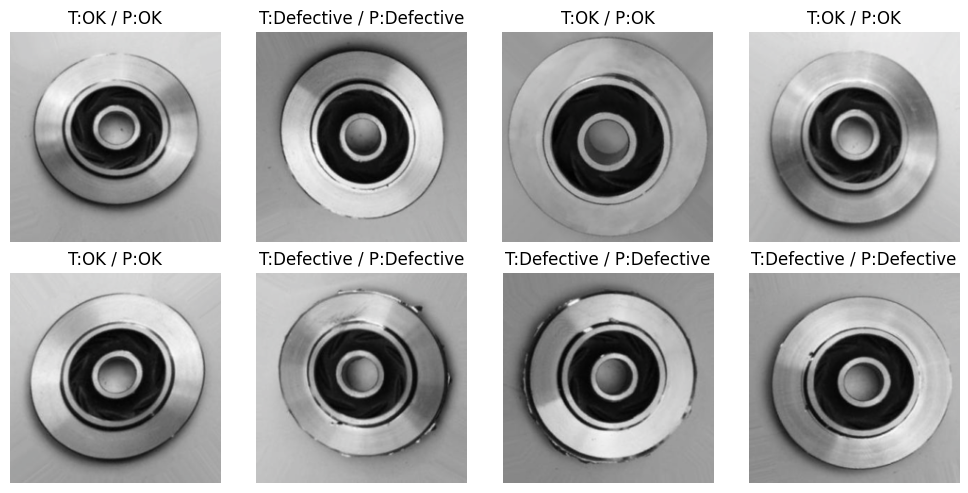

In [10]:
model.eval(); x, y = next(iter(test_dl)); x = x.to(device)
with torch.no_grad(): pred = model(x).argmax(1).cpu().numpy()
fig, axes = plt.subplots(2,4,figsize=(10,5))
for ax, img, actual, guess in zip(axes.ravel(), x.cpu(), y.numpy(), pred): ax.imshow(img.permute(1,2,0).numpy()*std+mean); ax.set_title(f'T:{list(label_id)[actual]} / P:{list(label_id)[guess]}'); ax.axis('off')
plt.tight_layout(); plt.savefig('phase3_representative_predictions.png',dpi=160); plt.show()